In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

def load_learning_logs(
        path: str = "/home/dopf02-admin/Carla-CTS02/logs/nava2c_nils/", 
        key: str = "decoupled", 
        reverse: bool = False
):
    merged_df = None
    # iterate from oldest to newest
    sorted_json_files = [file for file in sorted(glob.glob(path + "*.json"), key=os.path.getmtime) if key in file]
    if reverse: sorted_json_files.reverse()
    for idx, json_file_path in enumerate(sorted_json_files, 0):
        if key not in json_file_path: continue
        with open(json_file_path, "r") as file:
            file.readline()
            learning_log_df = pd.read_json(file, lines=True)
            print(
                f"learning metrics log file {idx}\n" +\
                f"from file: {json_file_path.split('/')[-1]}\n" +\
                f"has shape: {learning_log_df.shape}\n" +\
                f"and range: {learning_log_df.iloc[0,0]} -- {learning_log_df.iloc[-1,0]}"
            )
            if idx == 0: 
                merged_df = learning_log_df
                continue
            # make learning iterations continuous
            learning_log_df.iloc[:,0] += (merged_df.iloc[-1,0] - learning_log_df.iloc[0,0] + 1)  
            print(f"and corrected range: {learning_log_df.iloc[0,0]} -- {learning_log_df.iloc[-1,0]}")
            merged_df = pd.concat([merged_df, learning_log_df], axis="index")

    print(
        f"accumulated learning metric logs\n" 
        f"has shape: {merged_df.shape}\n"
        f"with columns {list(merged_df.columns)}"
    )
    return merged_df

In [2]:
def smooth(scalars: list, weight: float=0.99) -> list:  # Weight between 0 and 1
    '''
    The function used to smoothen the return vs episodes curve
    '''
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    std = 0
    var = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value
        
        delta = -1 if point - smoothed_val < -1 else point - smoothed_val
        var.append(delta)
    return smoothed, var

In [5]:
nava2c = load_learning_logs(path="/home/dopf02-admin/Carla-CTS02/logs/nava2c#2/train/", key="learning", reverse=False)

learning metrics log file 0
from file: learning_metrics_07.11.2024_17.16.11.json
has shape: (13406, 8)
and range: 2 -- 13407
learning metrics log file 1
from file: learning_metrics_09.11.2024_12.11.24.json
has shape: (674, 8)
and range: 13409 -- 14082
and corrected range: 13408 -- 14081
learning metrics log file 2
from file: learning_metrics_09.11.2024_14.46.32.json
has shape: (8057, 8)
and range: 14084 -- 22140
and corrected range: 14082 -- 22138
accumulated learning metric logs
has shape: (22137, 8)
with columns ['iteration', 'actor_loss', 'critic_loss', 'reward', 'entropy', 'explained_variance', 'kld', 'grad_norm']


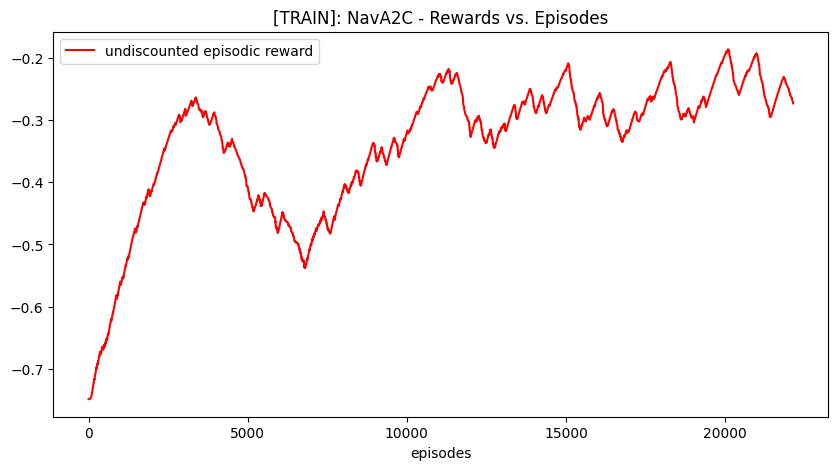

In [55]:
iteration = nava2c["iteration"].values

reward_smoothed, _ = smooth(nava2c["reward"].values.tolist(), weight=0.9996)
entropy_smoothed, _ = smooth(nava2c["entropy"].values.tolist())
explained_variance_smoothed, _ = smooth(nava2c["explained_variance"].values.tolist(), weight=0.999)
kld_smoothed, _ = smooth(nava2c["kld"].values.tolist(), weight=0.999)
grad_norm_smoothed, _ = smooth(nava2c["grad_norm"].values.tolist(), weight=0.999)

actor_loss_smoothed, _ = smooth(nava2c["actor_loss"].values.tolist())
critic_loss_smoothed, _ = smooth(nava2c["critic_loss"].values.tolist())
total_loss_smoothed, _ = smooth(
    np.add(nava2c["actor_loss"].values.tolist(), nava2c["critic_loss"].values.tolist()), weight=0.995
)

plt.plot(iteration, reward_smoothed, color="r", label="undiscounted episodic reward")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Rewards vs. Episodes")
plt.show()

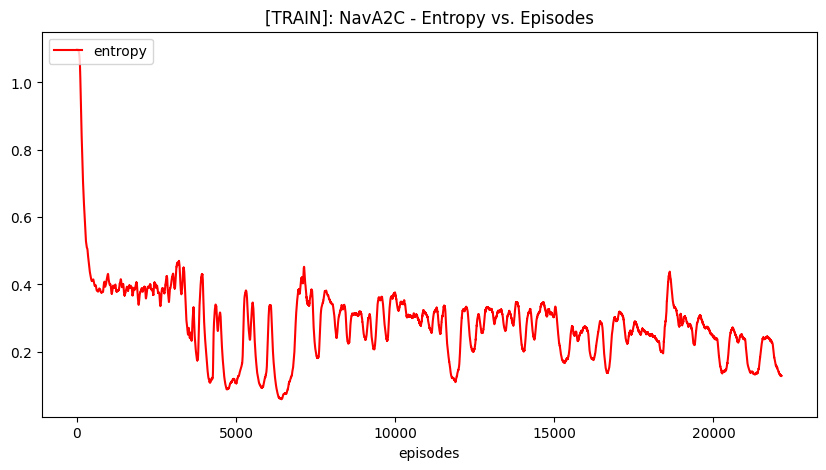

In [41]:
plt.plot(iteration, entropy_smoothed, color="r", label="entropy")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Entropy vs. Episodes")
plt.show()

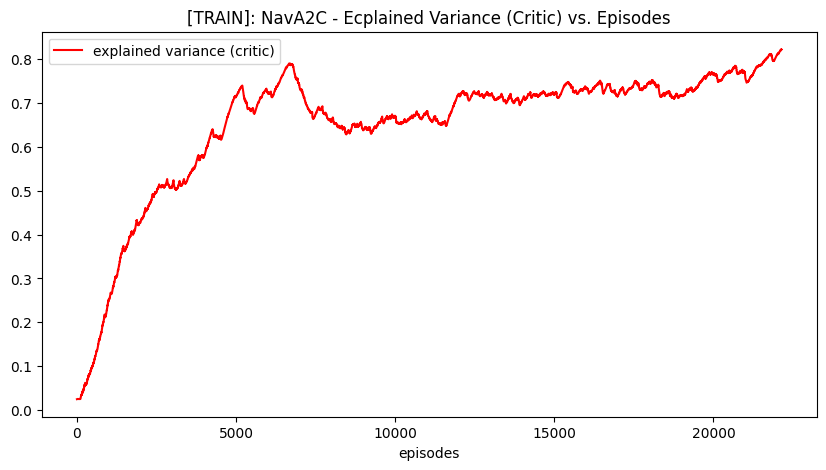

In [42]:
plt.plot(iteration, explained_variance_smoothed, color="r", label="explained variance (critic)")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Ecplained Variance (Critic) vs. Episodes")
plt.show()

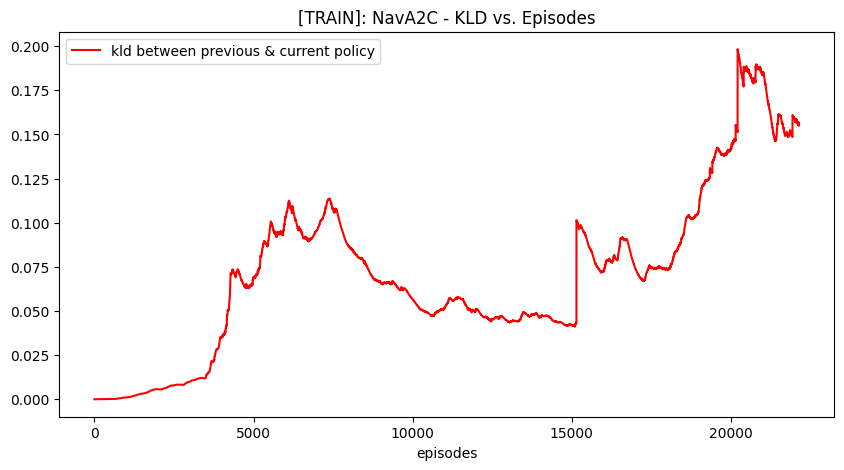

In [50]:
plt.plot(iteration, kld_smoothed, color="r", label="kld between previous & current policy")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - KLD vs. Episodes")
plt.show()

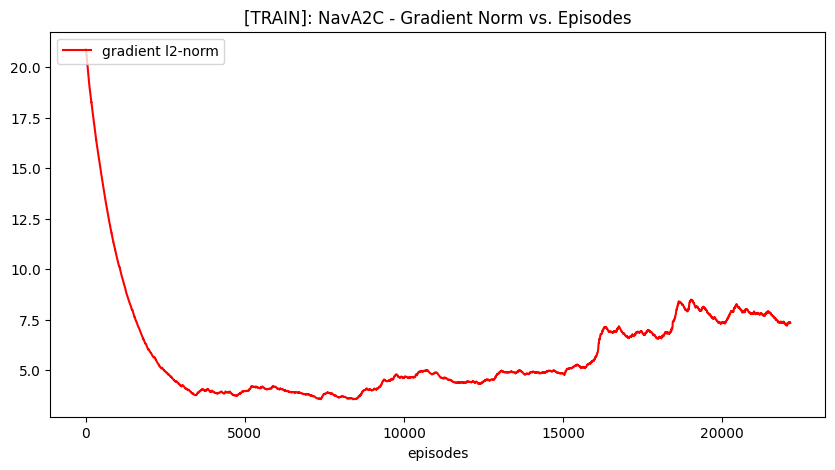

In [51]:
plt.plot(iteration, grad_norm_smoothed, color="r", label="gradient l2-norm")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Gradient Norm vs. Episodes")
plt.show()

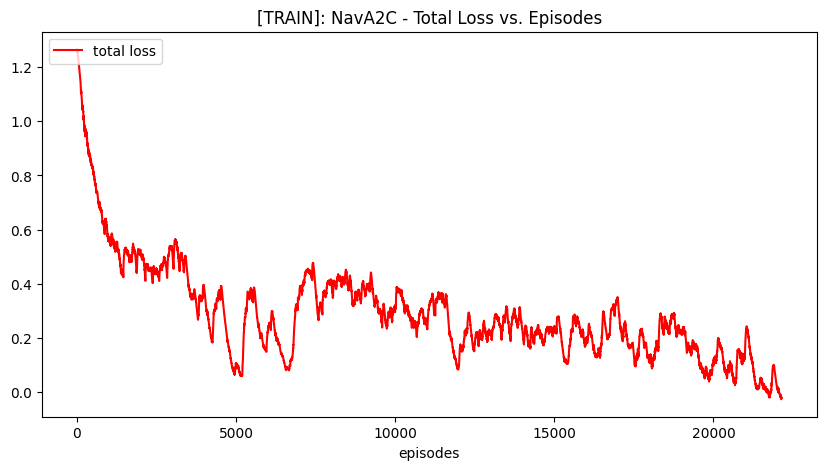

In [56]:
plt.plot(iteration, total_loss_smoothed, color="r", label="total loss")
plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Total Loss vs. Episodes")
plt.show()

In [77]:
nava2c_performance = load_learning_logs(
    path="/home/dopf02-admin/Carla-CTS02/logs/nava2c#2/train/", key="performance", reverse=False
)

learning metrics log file 0
from file: performance_metrics_S-ALL_07.11.2024_17.16.11.json
has shape: (13406, 15)
and range: 2 -- 13407
learning metrics log file 1
from file: performance_metrics_S-ALL_09.11.2024_12.11.24.json
has shape: (674, 15)
and range: 13409 -- 14082
and corrected range: 13408 -- 14081
learning metrics log file 2
from file: performance_metrics_S-ALL_09.11.2024_14.46.32.json
has shape: (8057, 15)
and range: 14084 -- 22140
and corrected range: 14082 -- 22138
accumulated learning metric logs
has shape: (22137, 15)
with columns ['episode', 'scenario', 'ped_distance', 'ped_speed', 'crash', 'nearmiss', 'goal', 'ttg', 'total_episode_reward', 'travelled_distance', 'execution_times', 'is_ped_observable', 'car_speeds', 'terminated_early', 'skipped_steps']


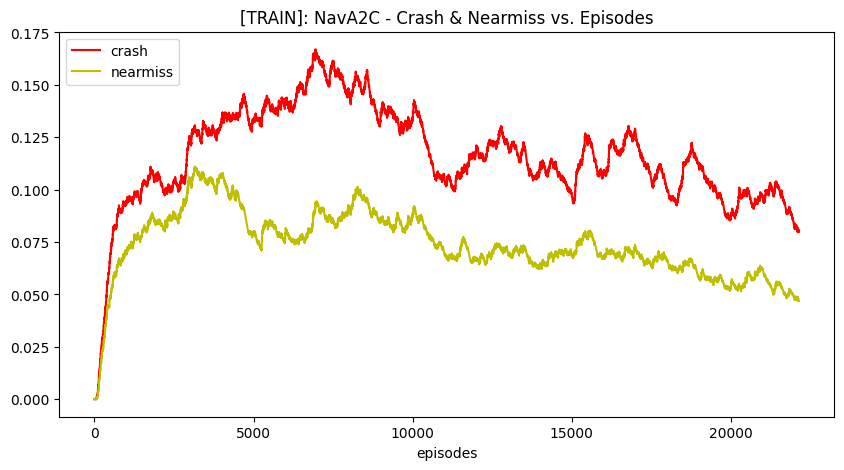

In [78]:
crash_smoothed, _ = smooth(nava2c_performance["crash"].values.tolist(), weight=0.999)
nearmiss_smoothed, _ = smooth(nava2c_performance["nearmiss"].values.tolist(), weight=0.999)

plt.plot(iteration, crash_smoothed, color="r", label="crash")
plt.plot(iteration, nearmiss_smoothed, color="y", label="nearmiss")

plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - Crash & Nearmiss vs. Episodes")
plt.show()

In [84]:
not_nan_rows = np.where(nava2c_performance["ttg"].notnull())[0]
print(len(not_nan_rows))
print(len(nava2c_performance["ttg"].dropna().values.tolist()))
iteration = nava2c_performance["episode"]
print(len(iteration))

iteration = iteration[not_nan_rows]
ttg_smoothed, _ = smooth(nava2c_performance["ttg"].dropna().values.tolist(), weight=0.99)

plt.plot(iteration, ttg_smoothed, color="g", label="ttg")

plt.xlabel("episodes")
plt.legend(loc="upper left")
plt.title("[TRAIN]: NavA2C - TTG vs. Episodes")
plt.show()

19279
19279
22137


KeyError: '[13406, 13407, 13408, 13409, 13411, 13413, 13414, 13415, 13416, 13417, 13418, 13419, 13420, 13421, 13422, 13423, 13425, 13427, 13429, 13430, 13431, 13432, 13433, 13435, 13436, 13437, 13438, 13439, 13441, 13442, 13443, 13444, 13445, 13446, 13447, 13448, 13449, 13451, 13452, 13453, 13454, 13455, 13457, 13458, 13459, 13460, 13461, 13462, 13463, 13464, 13467, 13468, 13469, 13471, 13472, 13473, 13474, 13475, 13477, 13478, 13481, 13482, 13483, 13484, 13485, 13486, 13487, 13488, 13489, 13490, 13491, 13492, 13493, 13494, 13495, 13496, 13497, 13498, 13499, 13500, 13501, 13502, 13503, 13505, 13506, 13507, 13508, 13509, 13510, 13511, 13512, 13513, 13515, 13516, 13517, 13518, 13519, 13520, 13521, 13522, 13523, 13524, 13525, 13526, 13527, 13528, 13529, 13530, 13531, 13533, 13534, 13535, 13536, 13537, 13538, 13539, 13540, 13541, 13542, 13543, 13544, 13545, 13546, 13547, 13548, 13549, 13550, 13551, 13552, 13553, 13554, 13555, 13556, 13557, 13558, 13559, 13560, 13561, 13562, 13563, 13564, 1